# Exploratory Data Analysis: Imaging Features

> This notebook explores the structure of the FreeSurfer-derived ROI features. We examine feature distributions, inter-feature correlations, and the geometry of the feature space via PCA and UMAP.

**Data:** Real ABCD analyses used N=2,387 participants with ComBat-harmonized features across 22 sites. Some demoed features use synthetic ROI features generated by `brainrisk.data.synthetic` (N=200, 400 features, 3 sites).

**Note:** The visualizations use aggregate, group-level summaries from ABCD data. All summaries have been previously disseminated in the author’s MSc thesis and do not permit identification of individual participants. This repository does not contain any ABCD Study data, subject-level results, or identifiable participant information. Some visualizations use synthetic data for reproducibility. Patterns in real data (e.g., subtype separability in UMAP space) are discussed in inline annotations where they differ.

In [ ]:
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)

from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from matplotlib_inline.backend_inline import set_matplotlib_formats
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

from brainrisk.data.synthetic import generate_clinical_data, generate_labels, generate_roi_features

# Figure resolution: adjust the DPI below to increase or decrease image quality.
# Currently set to 60 to keep the repository lightweight and fast to load.
set_matplotlib_formats('png')
mpl.rcParams["figure.dpi"] = 60
mpl.rcParams["savefig.dpi"] = 60

sns.set_theme(style="whitegrid", font_scale=1.1)
PALETTE = {"1": "#e66101", "2": "#5e3c99", "3": "#1b9e77", "PH−": "#636363"}

### 1. Generate & Load Synthetic Data

In [2]:
OUT = Path("../artifacts/notebook_scratch")
N, SEED = 200, 42

labels_df = generate_labels(n_subjects=N, seed=SEED, output_dir=OUT)
roi_df = generate_roi_features(n_subjects=N, n_features=400, n_sites=3, seed=SEED, output_dir=OUT)
clinical_df = generate_clinical_data(n_subjects=N, n_sites=3, seed=SEED, output_dir=OUT, labels=labels_df)

merged = roi_df.merge(clinical_df[["subject_id", "hydra_subtype", "sex"]], on="subject_id")
feature_cols = [c for c in roi_df.columns if c not in {"subject_id", "site"}]

print(f"Subjects: {len(merged)}  |  Features: {len(feature_cols)}  |  Sites: {merged['site'].nunique()}")
print(f"Subtype distribution: {merged['hydra_subtype'].value_counts().sort_index().to_dict()}")

Subjects: 200  |  Features: 400  |  Sites: 3
Subtype distribution: {1: 63, 2: 69, 3: 68}


### 2. Feature Distributions

FreeSurfer ROI features span different measurement families: cortical thickness (mm), surface area (mm²), subcortical volumes (mm³), gray–white contrast, and neurite density index, each with characteristic scales and distributional shapes. The synthetic generator preserves these family-specific ranges.

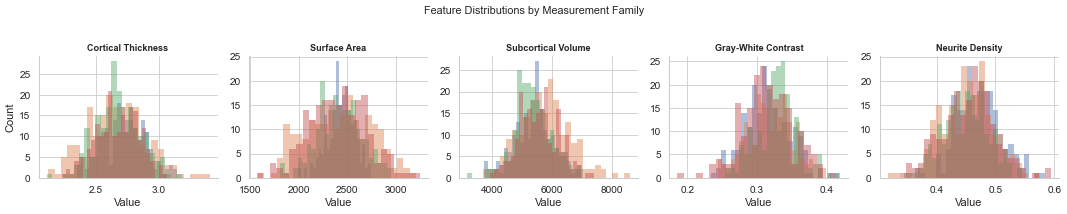

In [3]:
# Select representative features from different measurement families
families = {
    "Cortical Thickness": [c for c in feature_cols if c.endswith("_thickness")][:4],
    "Surface Area":       [c for c in feature_cols if c.endswith("_area")][:4],
    "Subcortical Volume": [c for c in feature_cols if "volume" in c.lower()][:4],
    "Gray-White Contrast":[c for c in feature_cols if c.endswith("_gwc")][:4],
    "Neurite Density":    [c for c in feature_cols if c.endswith("_ndi")][:4],
}

fig, axes = plt.subplots(1, len(families), figsize=(18, 3.5), sharey=False)
for ax, (family, cols) in zip(axes, families.items()):
    for col in cols:
        ax.hist(merged[col], bins=25, alpha=0.45, edgecolor="none")
    ax.set_title(family, fontsize=11, fontweight="bold")
    ax.set_xlabel("Value")
    ax.spines[["top", "right"]].set_visible(False)
axes[0].set_ylabel("Count")
fig.suptitle("Feature Distributions by Measurement Family", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### 3. Correlation Structure

Multi-modal neuroimaging features exhibit characteristic block-diagonal structure: strong within-family correlations (bilateral homologues, same-region measures) and weaker cross-family correlations.

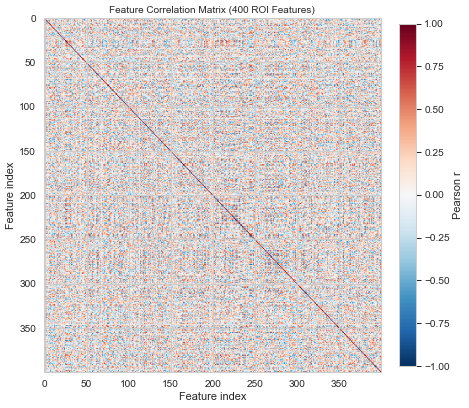

In [4]:
# Standardize features
X = StandardScaler().fit_transform(merged[feature_cols])
corr = np.corrcoef(X.T)

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
ax.set_title("Feature Correlation Matrix (400 ROI Features)", fontsize=12)
ax.set_xlabel("Feature index")
ax.set_ylabel("Feature index")
plt.colorbar(im, ax=ax, fraction=0.046, label="Pearson r")
plt.tight_layout()
plt.show()

**Pattern:** In the ABCD dataset, the correlation matrix shows pronounced block structure along the diagonal: bilateral cortical measures (lh/rh pairs) are highly correlated (r > 0.7), while cross-modal correlations (e.g., thickness vs. NDI) are substantially weaker (r ≈ 0.1–0.3).

### 3. PCA: Variance Explained

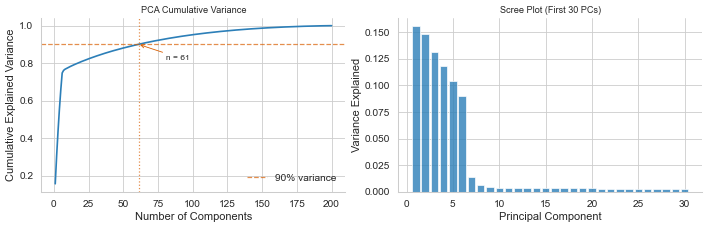

Components for 90% variance: 61 / 400


In [5]:
pca = PCA(random_state=42).fit(X)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Cumulative variance
cum_var = np.cumsum(pca.explained_variance_ratio_)
ax1.plot(range(1, len(cum_var)+1), cum_var, color="#2c7fb8", lw=2)
ax1.axhline(0.90, ls="--", color="#d95f02", alpha=0.7, label="90% variance")
n90 = np.searchsorted(cum_var, 0.90) + 1
ax1.axvline(n90, ls=":", color="#d95f02", alpha=0.7)
ax1.annotate(f"n = {n90}", xy=(n90, 0.90), xytext=(n90+20, 0.82),
             fontsize=10, arrowprops=dict(arrowstyle="->", color="#d95f02"))
ax1.set_xlabel("Number of Components")
ax1.set_ylabel("Cumulative Explained Variance")
ax1.set_title("PCA Cumulative Variance", fontsize=11)
ax1.legend(frameon=False)
ax1.spines[["top", "right"]].set_visible(False)

# Scree plot (first 30)
ax2.bar(range(1, 31), pca.explained_variance_ratio_[:30], color="#2c7fb8", alpha=0.8)
ax2.set_xlabel("Principal Component")
ax2.set_ylabel("Variance Explained")
ax2.set_title("Scree Plot (First 30 PCs)", fontsize=11)
ax2.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()
print(f"Components for 90% variance: {n90} / {len(feature_cols)}")

### 5. t-SNE/UMAP Visualizations (ABCD results)

UMAP provides a nonlinear embedding that better captures local structure in high-dimensional neuroimaging data. In the ABCD dataset, HYDRA subtypes partially overlap in UMAP space, consistent with the subtle, distributed nature of the subtype signal.

**Real-data finding:** In the UMAP of FreeSurfer ROI features, PH+ subtypes show partial but incomplete separation. The overlap is expected: HYDRA subtypes are defined by multi-modal imaging patterns that are individually subtle.

In [6]:
show_real_abcd: bool = True

if not show_real_abcd:
    try:
        from sklearn.manifold import TSNE
        tsne = TSNE(n_components=2, perplexity=30, random_state=42, init="pca")
        emb = tsne.fit_transform(X)

        fig, ax = plt.subplots(figsize=(7, 6))
        for st in sorted(merged["hydra_subtype"].unique()):
            mask = merged["hydra_subtype"] == st
            ax.scatter(emb[mask, 0], emb[mask, 1], s=20, alpha=0.55,
                    label=f"Subtype {st}", color=list(PALETTE.values())[st-1])
        ax.set_xlabel("t-SNE 1")
        ax.set_ylabel("t-SNE 2")
        ax.set_title("t-SNE: Synthetic ROI Features by HYDRA Subtype")
        ax.legend(frameon=False, markerscale=1.5)
        ax.spines[["top", "right"]].set_visible(False)
        plt.tight_layout()
        plt.show()
    except ImportError:
        print("t-SNE visualization requires sklearn ≥ 1.0")

<p align="left">
  <img src="figures/umap_plot.jpg"
       alt="NiT sex classification Phase 3 training accuracy"
       width="30%" />
</p>

### 6. Site Effects

Multi-site neuroimaging data carries systematic scanner/protocol differences. The synthetic generator injects mild site effects. In real analyses, ComBat harmonization was applied before any downstream modeling.

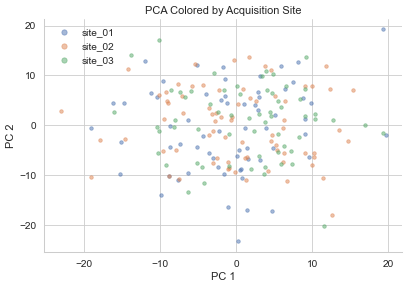

In [7]:
pca2d = PCA(n_components=2, random_state=42).fit_transform(X)

# Show site distribution across first 2 PCs
fig, ax = plt.subplots(figsize=(7, 5))
for site in sorted(merged["site"].unique()):
    mask = merged["site"] == site
    ax.scatter(pca2d[mask, 0], pca2d[mask, 1], s=18, alpha=0.5, label=site)
ax.set_xlabel("PC 1")
ax.set_ylabel("PC 2")
ax.set_title("PCA Colored by Acquisition Site")
ax.legend(frameon=False, markerscale=1.5)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

---
**Summary:** The ROI feature space has characteristic correlation structure, moderate intrinsic dimensionality (~50–100 PCs for 90% variance in real data), and subtle subtype-related geometry that motivates semi-supervised clustering (HYDRA) over unsupervised approaches. See `03_hydra_analysis.ipynb` for the clustering analysis.